# Allocator Benchmark Analysis
Drop your benchmark JSON files into the `JSON_FILES` list and run all cells.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

## Config — edit this cell

In [4]:
JSON_FILES = [
    "../small_allocs.json",
    # "results_batch.json",
    # "results_varying_size.json",
]

# Strip these from benchmark names to keep labels short
STRIP_PREFIXES = ["BM_"]
STRIP_SUFFIXES = ["_SmallAllocs", "_Batch", "_VaryingSize", "_Fragmented"]

## Load and parse

In [5]:
def clean_name(name: str) -> str:
    for p in STRIP_PREFIXES:
        name = name.removeprefix(p)
    for s in STRIP_SUFFIXES:
        name = name.removesuffix(s)
    return name

def load_json(path: str) -> pd.DataFrame:
    with open(path) as f:
        raw = json.load(f)

    # Pull useful context fields into every row
    ctx = raw["context"]
    rows = [
        {
            "benchmark":  clean_name(b["name"]),
            "cpu_time":   b["cpu_time"],
            "real_time":  b["real_time"],
            "iterations": b["iterations"],
            "time_unit":  b["time_unit"],
            "run_type":   b["run_type"],
            "source":     path,
            "num_cpus":   ctx.get("num_cpus"),
            "mhz_per_cpu": ctx.get("mhz_per_cpu"),
        }
        for b in raw["benchmarks"]
        if b["run_type"] == "iteration"  # skip aggregate rows
    ]
    return pd.DataFrame(rows)

df = pd.concat([load_json(p) for p in JSON_FILES], ignore_index=True)
df

,benchmark,cpu_time,real_time,iterations,time_unit,run_type,source,num_cpus,mhz_per_cpu
0,SystemAllocator,34.877232,34.934446,22400000,ns,iteration,../small_allocs.json,12,3700
1,LinearArena,0.927734,0.963221,640000000,ns,iteration,../small_allocs.json,12,3700


## Quick stats

In [6]:
unit = df["time_unit"].iloc[0]
baseline = df["cpu_time"].iloc[0]

stats = df[["benchmark", "cpu_time", "iterations"]].copy()
stats["speedup_vs_first"] = (baseline / stats["cpu_time"]).round(2)
stats["cpu_time"] = stats["cpu_time"].round(3)
stats.columns = ["Benchmark", f"CPU time ({unit})", "Iterations", "Speedup vs first"]
stats

,Benchmark,CPU time (ns),Iterations,Speedup vs first
0,SystemAllocator,34.877,22400000,1.00
1,LinearArena,0.928,640000000,37.59


## Bar chart

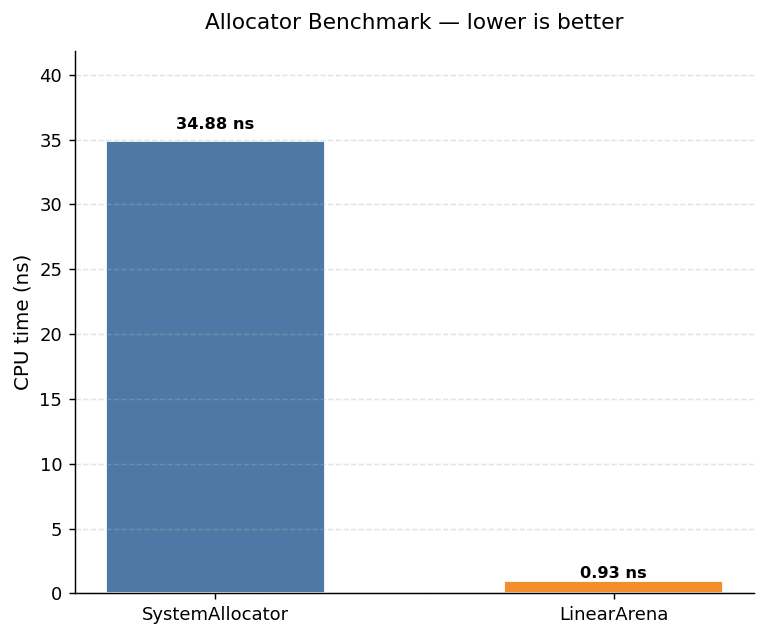

In [10]:
COLORS = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#edc948"]

labels = df["benchmark"].tolist()
times  = df["cpu_time"].tolist()
colors = [COLORS[i % len(COLORS)] for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 2), 5))

bars = ax.bar(labels, times, color=colors, width=0.55, edgecolor="white")

# Value labels on top of bars
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.02,
        f"{t:.2f} {unit}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax.set_ylabel(f"CPU time ({unit})", fontsize=11)
ax.set_title("Allocator Benchmark — lower is better", fontsize=12, pad=12)
ax.set_ylim(0, max(times) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150)
plt.show()

## Grouped bar chart (multiple JSON files)
Once you have results from multiple scenarios, this cell compares them side by side.
Each group is a scenario (file), each bar within the group is an allocator.

In [11]:
if df["source"].nunique() > 1:
    import numpy as np

    pivot = df.pivot(index="source", columns="benchmark", values="cpu_time")
    # Shorten source labels to filename stem
    pivot.index = [p.replace(".json", "").replace("results_", "") for p in pivot.index]

    allocators = pivot.columns.tolist()
    scenarios  = pivot.index.tolist()
    x = np.arange(len(scenarios))
    width = 0.8 / len(allocators)

    fig, ax = plt.subplots(figsize=(max(8, len(scenarios) * 2.5), 5))

    for i, alloc in enumerate(allocators):
        offset = (i - len(allocators) / 2 + 0.5) * width
        bars = ax.bar(x + offset, pivot[alloc], width, label=alloc,
                      color=COLORS[i % len(COLORS)], edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, fontsize=10)
    ax.set_ylabel(f"CPU time ({unit})", fontsize=11)
    ax.set_title("Allocator Benchmarks by Scenario — lower is better", fontsize=12, pad=12)
    ax.legend(title="Allocator", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.savefig("benchmark_grouped.png", dpi=150)
    plt.show()
else:
    print("Add more JSON files to JSON_FILES to see the grouped chart.")

Add more JSON files to JSON_FILES to see the grouped chart.
